# WQD7005 Assignment 1
## Name: Ridhwan Bin Razali
## Matrics Number: S2178595

## Section 1: Environment Setup & Imports

In [ ]:
import os
import json
import time
import warnings
import ydata_profiling
import pandas as pd
import numpy as np
import seaborn as sns
from openai import OpenAI
from dotenv import load_dotenv
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

Core libraries imported successfully
  - pandas: 2.3.3
  - numpy: 1.26.4
  - matplotlib: 3.7.5


In [34]:
# Load environment variables from .env file
load_dotenv(override=True)

# Get Azure OpenAI credentials
endpoint = os.getenv('AZURE_OPENAI_ENDPOINT')
api_key = os.getenv('AZURE_OPENAI_KEY')
deployment_name = os.getenv('AZURE_OPENAI_DEPLOYMENT_NAME', 'gpt-4.1')

# Verify credentials are set
if not endpoint or not api_key:
    print("Warning: Azure OpenAI credentials not found in environment")
    print("  Please add to .env file:")
    print("    AZURE_OPENAI_ENDPOINT=your_endpoint")
    print("    AZURE_OPENAI_KEY=your_key")
    print("    AZURE_OPENAI_DEPLOYMENT_NAME=gpt-4.1")
else:
    print("Azure OpenAI credentials loaded successfully")
    print(f"  Endpoint: {endpoint}")
    print(f"  Deployment: {deployment_name}")

# Initialize Azure OpenAI client
client = OpenAI(
    base_url=f"{endpoint}/openai/v1",
    api_key=api_key
)

Azure OpenAI credentials loaded successfully
  Endpoint: https://ridhwanopenai.openai.azure.com/
  Deployment: gpt-4.1


In [35]:
# Configuration for output directories
ARTIFACTS_DIR = "/home/ridhwanlaptop/assignment1_datamining/ridhwan/artifacts"
PROMPTS_DIR = "/home/ridhwanlaptop/assignment1_datamining/ridhwan/prompts"

# Ensure artifacts directory exists
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
print(f"Artifacts directory ready: {ARTIFACTS_DIR}")

Artifacts directory ready: /home/ridhwanlaptop/assignment1_datamining/ridhwan/artifacts


## Section 2: Task 1 - Generate Malaysian Patient Records via Azure (openai/gpt-4.1)

In [36]:
# Load the modified Malaysian patient generation prompt
prompt_file = os.path.join(PROMPTS_DIR, "patient_generation_prompt.md")

with open(prompt_file, "r") as f:
    prompt_template = f.read()

# Display first 500 characters of the prompt
print("Loaded Malaysian Patient Generation Prompt:")
print("=" * 70)
print(prompt_template[:500])
print("\n... [prompt continues] ...")
print("=" * 70)

Loaded Malaysian Patient Generation Prompt:
# Malaysian Patient Record Generation Prompt

## Task
Generate a realistic **single patient record** from a Malaysian healthcare setting. The record should represent a patient visiting a clinic, with current vital signs, symptoms, diagnosis, and medical history. Output **ONLY a valid JSON object** (no additional text or formatting).

## Patient Record Structure

Generate a JSON object with the following fields. All values must be realistic and plausible:

```json
{
  "patient_id": "<unique_id>",

... [prompt continues] ...


### Test the API from Azure OpenAI

In [37]:
# Quick test: Azure OpenAI API connectivity
print("Testing Azure OpenAI API connectivity...")
print("=" * 70)

try:
    completion = client.chat.completions.create(
        model=deployment_name,
        messages=[
            {
                "role": "user",
                "content": "Hello, say nasi lemak."
            }
        ],
        temperature=1,
        max_completion_tokens=100
    )
    response_text = completion.choices[0].message.content
    print("SUCCESS! Azure OpenAI API is working.")
    print(f"Response: {response_text}")
except Exception as e:
    print(f"FAILED! Azure OpenAI API error:")
    print(f"Error type: {type(e).__name__}")
    print(f"Error message: {str(e)}")

print("=" * 70)

Testing Azure OpenAI API connectivity...
SUCCESS! Azure OpenAI API is working.
Response: Hello! "Nasi lemak" is a popular Malaysian dish, often called the national dish of Malaysia. The name literally means "rich rice" or "creamy rice." The dish features rice cooked in coconut milk, served with anchovies (ikan bilis), peanuts, boiled or fried egg, sambal (spicy chili paste), cucumber, and often includes fried chicken or rendang. Have you tried nasi lemak before?


In [38]:
def generate_patient_batch(client, deployment_name, prompt_template, batch_size=10):
    """
    Generate a batch of patient records using Azure OpenAI API.
    
    Args:
        client: Azure OpenAI client instance
        deployment_name: Deployment name (e.g., gpt-5.1)
        prompt_template: The patient generation prompt
        batch_size: Number of patients to generate in this call
    
    Returns:
        patients_list: List of dictionaries containing patient data
        errors: List of error messages for failed generations
    """
    patients_list = []
    errors = []
    
    for i in range(batch_size):
        try:
            # Call Azure OpenAI API
            completion = client.chat.completions.create(
                model=deployment_name,
                messages=[
                    {
                        "role": "system",
                        "content": "You are a medical data generator. Generate realistic patient records in valid JSON format."
                    },
                    {
                        "role": "user",
                        "content": prompt_template
                    }
                ],
                temperature=1,
                max_completion_tokens=1024
            )
            
            # Extract the response
            response_text = completion.choices[0].message.content.strip()
            
            # Try to parse as JSON
            if "```json" in response_text:
                response_text = response_text.split("```json")[1].split("```")[0].strip()
            elif "```" in response_text:
                response_text = response_text.split("```")[1].split("```")[0].strip()
            
            patient_data = json.loads(response_text)
            patient_data["patient_id"] = f"P{i+1:04d}"
            patients_list.append(patient_data)
            
        except json.JSONDecodeError as e:
            errors.append(f"Batch item {i}: JSON parsing error - {str(e)}")
        except Exception as e:
            errors.append(f"Batch item {i}: API error - {str(e)}")
    
    return patients_list, errors

print("Patient batch generation function defined")
print(f"  - Model: Azure OpenAI (gpt-4.1)")
print(f"  - Batch size: 10 patients per API call")

Patient batch generation function defined
  - Model: Azure OpenAI (gpt-4.1)
  - Batch size: 10 patients per API call


### Generate 500 patient records in batches (Uncomment to run)
- 10 patient per batch is to ensure the data generated is consistent and preventing being rate limited

In [39]:
# # Generate 500 patient records in batches
# print("Starting patient record generation...")
# print("=" * 70)

# all_patients = []
# batch_count = 50  # 50 batches × 10 per batch = 500 patients
# batch_size = 10

# for batch_num in range(batch_count):
#     print(f"Batch {batch_num + 1}/{batch_count}...", end=" ", flush=True)
    
#     try:
#         patients_batch, errors = generate_patient_batch(
#             client,
#             deployment_name,
#             prompt_template, 
#             batch_size=batch_size
#         )
#         all_patients.extend(patients_batch)
        
#         if errors:
#             print(f"Generated {len(patients_batch)} patients (with {len(errors)} errors)")
#             for error in errors:
#                 print(f"   - {error}")
#         else:
#             print(f"Generated {len(patients_batch)} patients")
        
#         # Add delay between batches to avoid rate limiting
#         time.sleep(1)
        
#     except Exception as e:
#         print(f"Batch failed: {str(e)}")

# print("=" * 70)
# print(f"Total patients generated: {len(all_patients)}")
# print(f"  Target: 500 patients")
# print(f"  Success rate: {len(all_patients) / (batch_count * batch_size) * 100:.1f}%")

In [40]:
# # Flatten vital_signs nested dict and create DataFrame
# def flatten_patient_data(patients):
#     """Flatten nested vital_signs dictionary into separate columns"""
#     flattened = []
    
#     for patient in patients:
#         flat_patient = {
#             "patient_id": patient.get("patient_id", ""),
#             "name": patient.get("name", ""),
#             "gender": patient.get("gender", ""),
#             "age": patient.get("age", ""),
#             "date_of_birth": patient.get("date_of_birth", ""),
#             "visit_date": patient.get("visit_date", ""),
#             "visit_time": patient.get("visit_time", ""),
#             "ethnicity": patient.get("ethnicity", ""),
#             "symptoms": patient.get("symptoms", ""),
#             "diagnosis": patient.get("diagnosis", ""),
#             "medical_history": patient.get("medical_history", ""),
#             "allergies": patient.get("allergies", ""),
#             "current_medications": patient.get("current_medications", ""),
#             "notes": patient.get("notes", ""),
#         }
        
#         # Flatten vital_signs
#         vital_signs = patient.get("vital_signs", {})
#         for key, value in vital_signs.items():
#             flat_patient[f"vital_{key}"] = value
        
#         flattened.append(flat_patient)
    
#     return pd.DataFrame(flattened)

# # Create DataFrame from all patients
# df_patients = flatten_patient_data(all_patients)

# print("Patient data converted to DataFrame")
# print(f"\nDataFrame shape: {df_patients.shape}")
# print(f"\nColumn names:")
# print(f"  {list(df_patients.columns)}")
# print(f"\nFirst 3 rows:")
# df_patients.head(3)

In [41]:
# # Save generated patients to CSV
# csv_path = os.path.join(ARTIFACTS_DIR, "generated_patients.csv")
# df_patients.to_csv(csv_path, index=False)

# print(f"Saved {len(df_patients)} patient records to:")
# print(f"  {csv_path}")
# print(f"\nDataset Summary:")
# print(f"  - Total rows: {len(df_patients)}")
# print(f"  - Total columns: {len(df_patients.columns)}")
# print(f"  - Memory usage: {df_patients.memory_usage(deep=True).sum() / 1024:.2f} KB")
# print(f"\nData types:")
# print(df_patients.dtypes)

## Section 3: Task 2 - Exploratory Data Analysis with Charts

In [42]:
# Load existing generated_patients.csv instead of re-running generation
print("Loading pre-generated patient data...")
print("=" * 70)

csv_path = os.path.join(ARTIFACTS_DIR, "generated_patients.csv")

if os.path.exists(csv_path):
    try:
        df_patients = pd.read_csv(csv_path)
        print(f"Loaded {len(df_patients)} patient records from:")
        print(f"  {csv_path}")
        print(f"\nDataset Summary:")
        print(f"  - Total rows: {len(df_patients)}")
        print(f"  - Total columns: {len(df_patients.columns)}")
        print(f"  - Columns: {list(df_patients.columns)}")
    except Exception as e:
        print(f"Error loading CSV: {str(e)}")
        print("Will need to run generation instead.")
        df_patients = None
else:
    print(f"File not found: {csv_path}")
    print("Will need to run generation instead.")
    df_patients = None

if df_patients is None:
    print("\nYou need to run Task 1 generation first, or check the file path.")
else:
    print("=" * 70)

Loading pre-generated patient data...


Loaded 500 patient records from:
  /home/ridhwanlaptop/assignment1_datamining/ridhwan/artifacts/generated_patients.csv

Dataset Summary:
  - Total rows: 500
  - Total columns: 22
  - Columns: ['patient_id', 'name', 'gender', 'age', 'date_of_birth', 'visit_date', 'visit_time', 'ethnicity', 'symptoms', 'diagnosis', 'medical_history', 'allergies', 'current_medications', 'notes', 'vital_heart_rate', 'vital_systolic_bp', 'vital_diastolic_bp', 'vital_respiratory_rate', 'vital_temperature', 'vital_oxygen_saturation', 'vital_weight', 'vital_height']


In [43]:
# ========== ENSURE UNIQUE PATIENT IDs ACROSS ALL 500 RECORDS ==========
print("Ensuring unique patient IDs (P0001-P0500)...")
print("=" * 70)
df_patients['patient_id'] = [f"P{i+1:04d}" for i in range(len(df_patients))]
print(f"✓ Patient IDs reassigned: {df_patients['patient_id'].nunique()} unique IDs for {len(df_patients)} patients")
print(f"  Range: {df_patients['patient_id'].min()} to {df_patients['patient_id'].max()}")

# Verify no duplicates
dupes = df_patients[df_patients.duplicated('patient_id', keep=False)]
if len(dupes) == 0:
    print("✓ No duplicate patient_ids found!")
else:
    print(f"⚠ Warning: {len(dupes)} records have duplicate IDs")
print("=" * 70)

Ensuring unique patient IDs (P0001-P0500)...
✓ Patient IDs reassigned: 500 unique IDs for 500 patients
  Range: P0001 to P0500
✓ No duplicate patient_ids found!


### Check if we have missing values

In [44]:
print(f"\nMissing Values Summary:")
missing_summary = df_patients.isnull().sum()
missing_pct = (missing_summary / len(df_patients) * 100).round(2)
missing_df = pd.DataFrame({
    "Column": missing_summary.index,
    "Missing_Count": missing_summary.values,
    "Missing_Percentage": missing_pct.values
})
missing_df = missing_df[missing_df["Missing_Count"] > 0].sort_values("Missing_Count", ascending=False)
print(missing_df.to_string(index=False))


Missing Values Summary:
Empty DataFrame
Columns: [Column, Missing_Count, Missing_Percentage]
Index: []


### Since theres no missing values generated by the LLM
#### We need to alter the dataset to have missing values as per the task 1 requirements.


In [45]:
# Set random seed for reproducibility
np.random.seed(42)

# Add missing values to the dataset
# Introduce missing values in various columns to simulate real-world data quality issues

# 1. Missing values in numerical columns (5-15% missing)
numerical_cols = ["age", "vital_heart_rate", "vital_systolic_bp", "vital_diastolic_bp", 
                  "vital_respiratory_rate", "vital_temperature", "vital_oxygen_saturation", "weight", "height"]

for col in numerical_cols:
    if col in df_patients.columns:
        # Randomly select 5-10% of rows to set as missing
        missing_percentage = np.random.uniform(0.05, 0.10)
        missing_indices = np.random.choice(df_patients.index, size=int(len(df_patients) * missing_percentage), replace=False)
        df_patients.loc[missing_indices, col] = np.nan

# 2. Missing values in categorical columns (3-8% missing)
categorical_cols_with_missing = ["allergies", "current_medications", "diagnosis"]

for col in categorical_cols_with_missing:
    if col in df_patients.columns:
        missing_percentage = np.random.uniform(0.03, 0.08)
        missing_indices = np.random.choice(df_patients.index, size=int(len(df_patients) * missing_percentage), replace=False)
        df_patients.loc[missing_indices, col] = np.nan

print(" Missing values added to the dataset")
print("\nUpdated Missing Values Summary:")
missing_summary = df_patients.isnull().sum()
missing_pct = (missing_summary / len(df_patients) * 100).round(2)
missing_detail_df = pd.DataFrame({
    "Column": missing_summary.index,
    "Missing_Count": missing_summary.values,
    "Missing_Percentage": missing_pct.values
})
missing_detail_df = missing_detail_df[missing_detail_df["Missing_Count"] > 0].sort_values("Missing_Count", ascending=False)
print(missing_detail_df.to_string(index=False))

 Missing values added to the dataset

Updated Missing Values Summary:
                 Column  Missing_Count  Missing_Percentage
       vital_heart_rate             48                 9.6
vital_oxygen_saturation             43                 8.6
 vital_respiratory_rate             36                 7.2
                    age             34                 6.8
              diagnosis             34                 6.8
              allergies             32                 6.4
     vital_diastolic_bp             32                 6.4
      vital_systolic_bp             27                 5.4
      vital_temperature             27                 5.4
    current_medications             19                 3.8


## Section 3.1 : Outlier Detection & Analysis (Before Imputation)

**Strategy**: Visualize and analyze outliers FIRST, then decide imputation methods based on actual data distribution.


STEP 1: OUTLIER VISUALIZATION & DETECTION


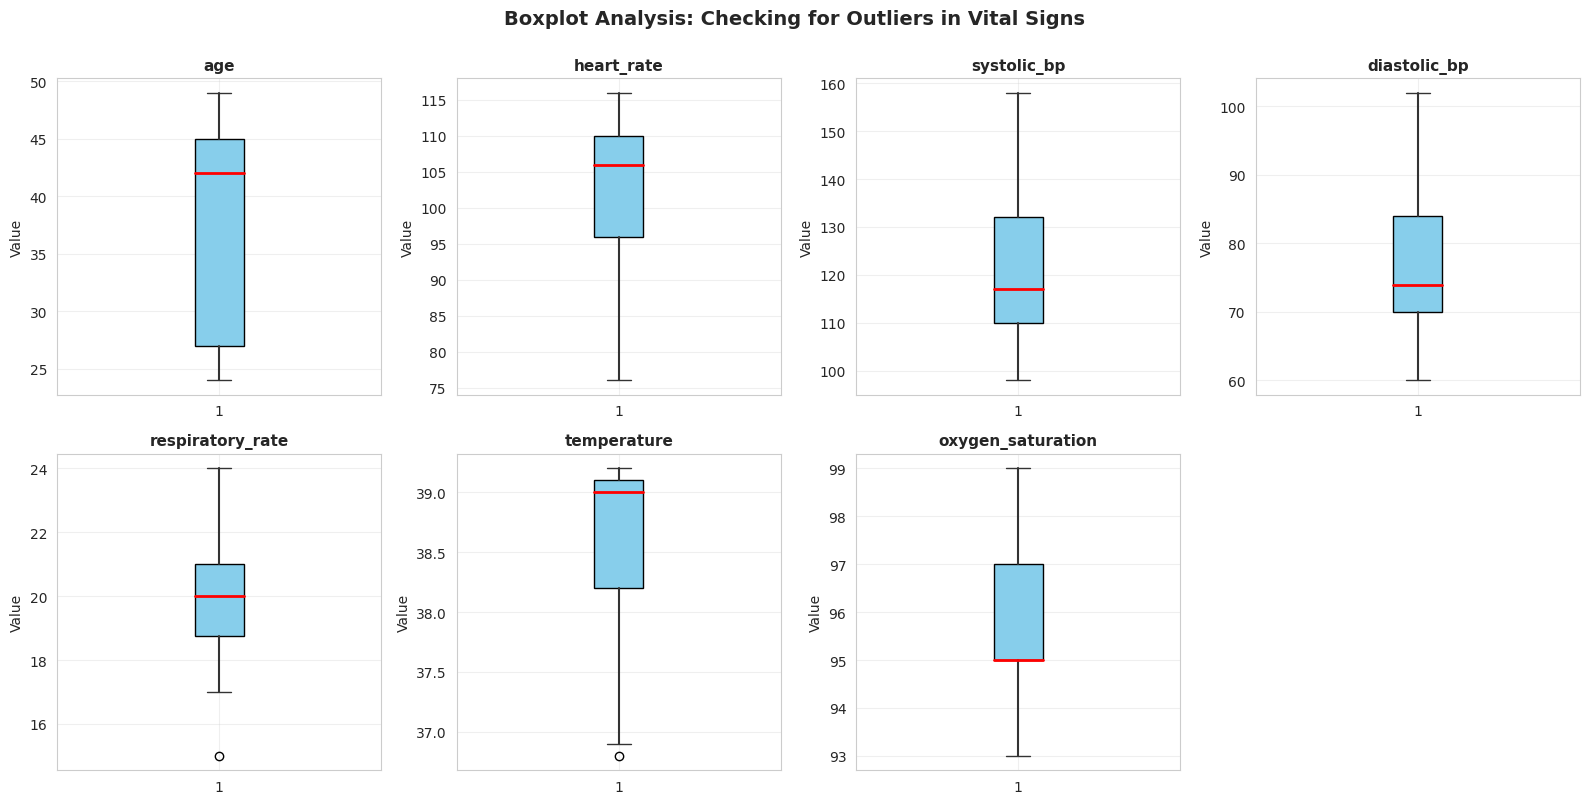

In [46]:
# Visualize outliers using boxplots
print("STEP 1: OUTLIER VISUALIZATION & DETECTION")
print("=" * 70)

# Prepare data for visualization
vital_cols_to_check = ["age", "vital_heart_rate", "vital_systolic_bp", "vital_diastolic_bp", 
                       "vital_respiratory_rate", "vital_temperature", "vital_oxygen_saturation"]

# Convert to numeric first (ignore missing values)
df_numeric = df_patients[vital_cols_to_check].copy()
for col in df_numeric.columns:
    df_numeric[col] = pd.to_numeric(df_numeric[col], errors="coerce")

# Create boxplots
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, col in enumerate(vital_cols_to_check):
    ax = axes[idx]
    box = ax.boxplot(df_numeric[col].dropna(), vert=True, patch_artist=True)
    
    # Color the box
    for patch in box['boxes']:
        patch.set_facecolor('#87CEEB')
    for whisker in box['whiskers']:
        whisker.set_color('#333333')
        whisker.set_linewidth(1.5)
    for cap in box['caps']:
        cap.set_color('#333333')
    for median in box['medians']:
        median.set_color('red')
        median.set_linewidth(2)
    
    ax.set_title(col.replace('vital_', ''), fontsize=11, fontweight='bold')
    ax.set_ylabel('Value')
    ax.grid(alpha=0.3)

# Remove extra subplot
axes[-1].remove()

plt.suptitle('Boxplot Analysis: Checking for Outliers in Vital Signs', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, "outlier_boxplots.png"), dpi=100, bbox_inches="tight")
plt.show()


In [47]:
# Statistical Outlier Detection: IQR Method
print("\nSTEP 2: STATISTICAL OUTLIER DETECTION (IQR METHOD)")
print("=" * 70)

outlier_summary = []

for col in vital_cols_to_check:
    data = df_numeric[col].dropna()
    
    if len(data) > 0:
        # Calculate IQR
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        
        # Define fences (outliers beyond 1.5 * IQR)
        lower_fence = Q1 - 1.5 * IQR
        upper_fence = Q3 + 1.5 * IQR
        
        # Count outliers
        outliers = data[(data < lower_fence) | (data > upper_fence)]
        outlier_count = len(outliers)
        outlier_pct = (outlier_count / len(data)) * 100
        
        # Z-score method (values beyond ±3 std devs)
        mean_val = data.mean()
        std_val = data.std()
        z_scores = np.abs((data - mean_val) / std_val)
        extreme_outliers = (z_scores > 3).sum()
        
        outlier_summary.append({
            "Column": col,
            "Count": len(data),
            "Missing": df_patients[col].isnull().sum(),
            "Q1": Q1,
            "Median": data.median(),
            "Q3": Q3,
            "IQR": IQR,
            "Lower_Fence": lower_fence,
            "Upper_Fence": upper_fence,
            "Outliers_IQR": outlier_count,
            "Outliers_%": round(outlier_pct, 2),
            "Extreme_Outliers": extreme_outliers,
            "Mean": round(mean_val, 2),
            "Std": round(std_val, 2)
        })

outlier_df = pd.DataFrame(outlier_summary)

# Display summary
print("\nOutlier Summary (IQR Method):")
print(outlier_df[["Column", "Count", "Missing", "Outliers_IQR", "Outliers_%", "Extreme_Outliers", "Mean", "Median", "Std"]].to_string(index=False))

print("\n" + "-" * 70)
print("KEY INSIGHTS:")
for _, row in outlier_df.iterrows():
    if row["Outliers_%"] > 0:
        print(f"  • {row['Column']:30} → {row['Outliers_IQR']} outliers ({row['Outliers_%']:.2f}%)")
        if row["Mean"] != row["Median"] and abs(row["Mean"] - row["Median"]) > 0.5:
            print(f"     Mean ({row['Mean']}) ≠ Median ({row['Median']:.2f}) → Suggests potential outliers distorting mean!")
        else:
            print(f"    ✓ Mean and Median close → Data is relatively symmetric")



STEP 2: STATISTICAL OUTLIER DETECTION (IQR METHOD)

Outlier Summary (IQR Method):
                 Column  Count  Missing  Outliers_IQR  Outliers_%  Extreme_Outliers   Mean  Median   Std
                    age    466       34             0        0.00                 0  37.17    42.0  8.46
       vital_heart_rate    452       48             0        0.00                 2 103.50   106.0  7.24
      vital_systolic_bp    473       27             0        0.00                 0 120.08   117.0 15.14
     vital_diastolic_bp    468       32             0        0.00                 0  76.67    74.0  9.20
 vital_respiratory_rate    464       36             1        0.22                 6  19.79    20.0  1.39
      vital_temperature    473       27             1        0.21                 5  38.66    39.0  0.57
vital_oxygen_saturation    457       43             0        0.00                 0  95.68    95.0  1.24

----------------------------------------------------------------------
KEY I

### Basic Statistics of the dataset


In [48]:
# Convert age to numeric for analysis (using CLEANED data)
df_patients["age"] = pd.to_numeric(df_patients["age"], errors="coerce")

print("Dataset Overview (From CLEANED Data):")
print("=" * 70)
print(f"Shape: {df_patients.shape}")
print(f"\nBasic Statistics (After Cleaning & Imputation):")
print(df_patients.describe().to_string())

Dataset Overview (From CLEANED Data):
Shape: (500, 22)

Basic Statistics (After Cleaning & Imputation):
              age  vital_heart_rate  vital_systolic_bp  vital_diastolic_bp  vital_respiratory_rate  vital_temperature  vital_oxygen_saturation  vital_weight  vital_height
count  466.000000        452.000000         473.000000          468.000000              464.000000         473.000000               457.000000    500.000000    500.000000
mean    37.165236        103.495575         120.082452           76.668803               19.793103          38.661734                95.682713     64.402600    161.136000
std      8.459172          7.235811          15.144627            9.201720                1.388115           0.569488                 1.236323      8.823859      5.136367
min     24.000000         76.000000          98.000000           60.000000               15.000000          36.800000                93.000000     50.200000    155.000000
25%     27.000000         96.000000      

In [49]:
df_patients.head()
print(f"\nUnique Value Counts for Categorical Columns (CLEANED Data):")
categorical_cols = ["gender", "ethnicity", "diagnosis", "allergies", "current_medications"]

print(f"  - Categorical columns: {categorical_cols}")
for col in categorical_cols:
    unique_values = df_patients[col].dropna().unique()
    print(f"    - {col}: {len(unique_values)} unique values")
    print(f"      Sample: {unique_values[:5]}")


Unique Value Counts for Categorical Columns (CLEANED Data):
  - Categorical columns: ['gender', 'ethnicity', 'diagnosis', 'allergies', 'current_medications']
    - gender: 2 unique values
      Sample: ['F' 'M']
    - ethnicity: 2 unique values
      Sample: ['Malay' 'Chinese']
    - diagnosis: 53 unique values
      Sample: ['Uncontrolled Type 2 Diabetes Mellitus with UTI'
 'Dengue Fever (probable)' 'Dengue Fever' 'Suspected Dengue Fever'
 'Dengue Fever (Uncomplicated)']
    - allergies: 14 unique values
      Sample: ['none' 'NSAIDs' 'Paracetamol' 'Ibuprofen' 'Sulfa drugs']
    - current_medications: 43 unique values
      Sample: ['Metformin, Losartan' 'Amlodipine' 'Paracetamol' 'none' 'paracetamol']


### Plot charts for analysis

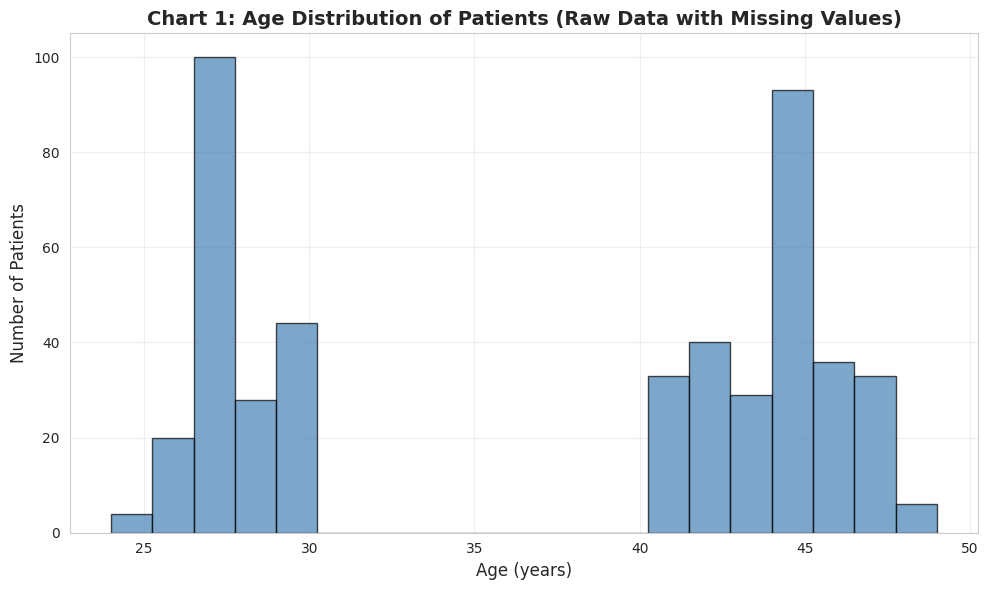

✓ Chart 1 saved to chart_1_age_distribution.png


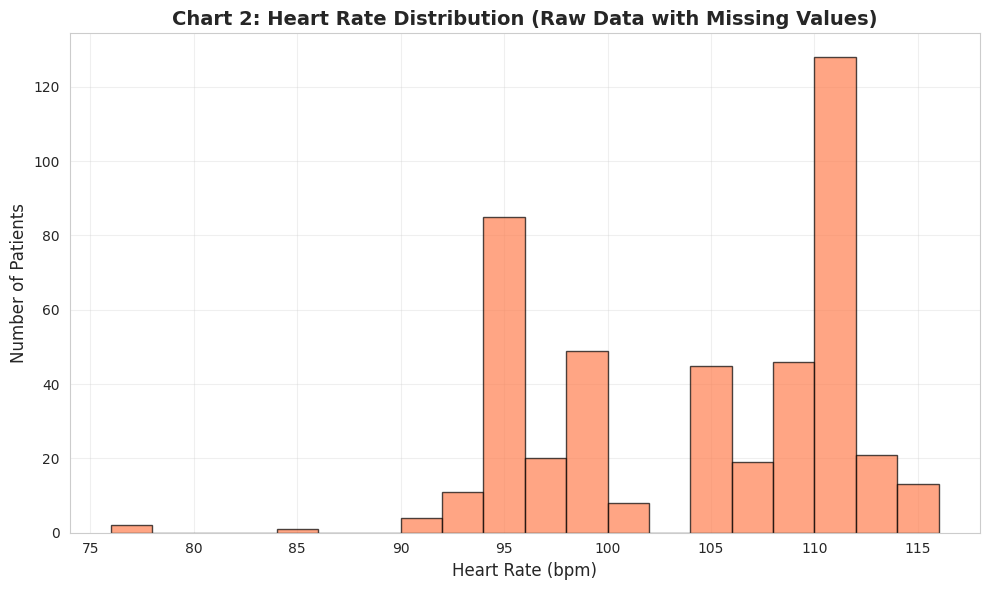

✓ Chart 2 saved to chart_2_heart_rate_distribution.png


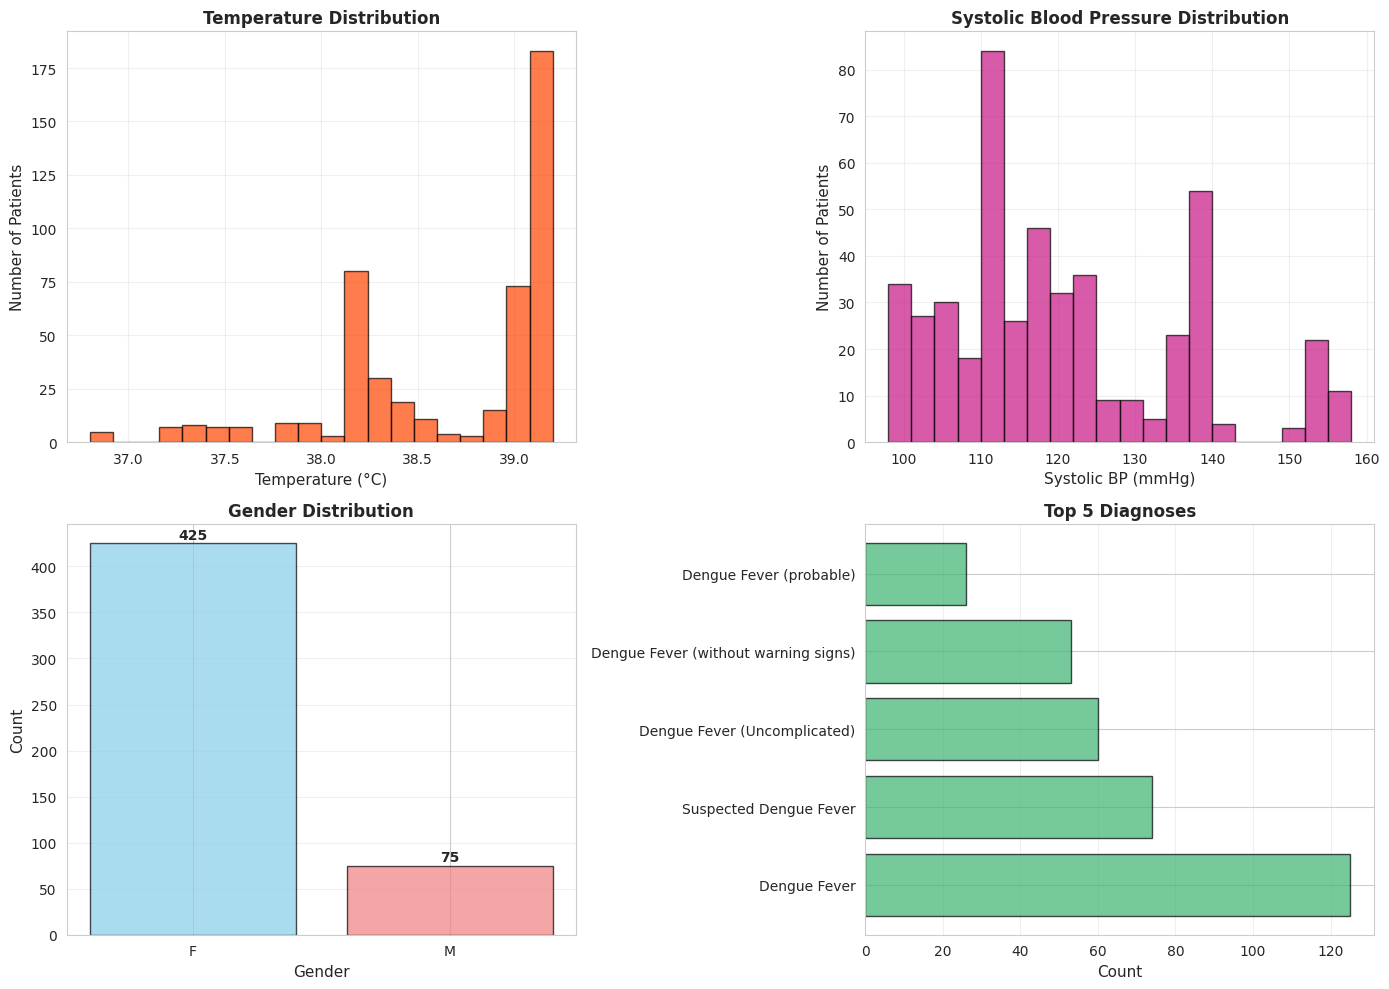

✓ Chart 3 saved to chart_3_vital_signs_demographics.png

✓ All charts created and saved separately to artifacts folder


In [50]:
# Set up plotting style
sns.set_style("whitegrid")

# Chart 1: Age distribution (RAW DATA - SHOWS MISSING VALUES)
fig1, ax1 = plt.subplots(figsize=(10, 6))
age_data = df_patients["age"].dropna()
ax1.hist(age_data, bins=20, color="steelblue", alpha=0.7, edgecolor="black")
ax1.set_xlabel("Age (years)", fontsize=12)
ax1.set_ylabel("Number of Patients", fontsize=12)
ax1.set_title("Chart 1: Age Distribution of Patients (Raw Data with Missing Values)", fontsize=14, fontweight="bold")
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, "chart_1_age_distribution.png"), dpi=100, bbox_inches="tight")
plt.show()
print("✓ Chart 1 saved to chart_1_age_distribution.png")

# Chart 2: Heart Rate Distribution (RAW DATA - SHOWS MISSING VALUES)
fig2, ax2 = plt.subplots(figsize=(10, 6))
hr_data = pd.to_numeric(df_patients["vital_heart_rate"], errors="coerce").dropna()
ax2.hist(hr_data, bins=20, color="coral", alpha=0.7, edgecolor="black")
ax2.set_xlabel("Heart Rate (bpm)", fontsize=12)
ax2.set_ylabel("Number of Patients", fontsize=12)
ax2.set_title("Chart 2: Heart Rate Distribution (Raw Data with Missing Values)", fontsize=14, fontweight="bold")
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, "chart_2_heart_rate_distribution.png"), dpi=100, bbox_inches="tight")
plt.show()
print("✓ Chart 2 saved to chart_2_heart_rate_distribution.png")

# Chart 3: Multiple Vital Signs & Demographics (2x2 subplots)
fig3, axes = plt.subplots(2, 2, figsize=(14, 10))

# Subplot 1: Temperature Distribution
temp_data = pd.to_numeric(df_patients["vital_temperature"], errors="coerce").dropna()
axes[0, 0].hist(temp_data, bins=20, color="orangered", alpha=0.7, edgecolor="black")
axes[0, 0].set_xlabel("Temperature (°C)", fontsize=11)
axes[0, 0].set_ylabel("Number of Patients", fontsize=11)
axes[0, 0].set_title("Temperature Distribution", fontsize=12, fontweight="bold")
axes[0, 0].grid(alpha=0.3)

# Subplot 2: Systolic Blood Pressure Distribution
sbp_data = pd.to_numeric(df_patients["vital_systolic_bp"], errors="coerce").dropna()
axes[0, 1].hist(sbp_data, bins=20, color="mediumvioletred", alpha=0.7, edgecolor="black")
axes[0, 1].set_xlabel("Systolic BP (mmHg)", fontsize=11)
axes[0, 1].set_ylabel("Number of Patients", fontsize=11)
axes[0, 1].set_title("Systolic Blood Pressure Distribution", fontsize=12, fontweight="bold")
axes[0, 1].grid(alpha=0.3)

# Subplot 3: Gender Distribution
gender_data = df_patients["gender"].value_counts()
axes[1, 0].bar(gender_data.index, gender_data.values, color=["skyblue", "lightcoral"], alpha=0.7, edgecolor="black")
axes[1, 0].set_xlabel("Gender", fontsize=11)
axes[1, 0].set_ylabel("Count", fontsize=11)
axes[1, 0].set_title("Gender Distribution", fontsize=12, fontweight="bold")
axes[1, 0].grid(alpha=0.3, axis="y")
for i, v in enumerate(gender_data.values):
    axes[1, 0].text(i, v + 5, str(v), ha="center", fontweight="bold")

# Subplot 4: Top 5 Diagnoses
top_diagnoses = df_patients["diagnosis"].value_counts().head(5)
axes[1, 1].barh(range(len(top_diagnoses)), top_diagnoses.values, color="mediumseagreen", alpha=0.7, edgecolor="black")
axes[1, 1].set_yticks(range(len(top_diagnoses)))
axes[1, 1].set_yticklabels(top_diagnoses.index, fontsize=10)
axes[1, 1].set_xlabel("Count", fontsize=11)
axes[1, 1].set_title("Top 5 Diagnoses", fontsize=12, fontweight="bold")
axes[1, 1].grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, "chart_3_vital_signs_demographics.png"), dpi=100, bbox_inches="tight")
plt.show()
print("✓ Chart 3 saved to chart_3_vital_signs_demographics.png")

print("\n✓ All charts created and saved separately to artifacts folder")

### (My own) Charts analysis
- Demographics: The dataset is heavily female-dominant (425 vs. 75 males, ~85%). Age distribution is bimodal, with two clear peaks around 27 years and 44–45 years, and a noticeable gap in patients aged 30–40.

- Fever & Heart Rate: Temperature is strongly skewed toward high fever, with a major concentration at >39.0°C. This directly aligns with the heart rate data, which shows a dominant cluster at 105–115 bpm, indicating tachycardia likely driven by the febrile response.

- Blood Pressure: Systolic BP shows a dual pattern. A large group clusters around a healthy 110–115 mmHg, but a secondary, significant cluster appears near 138–140 mmHg.

- Diagnoses: The chart is overwhelmingly dominated by Dengue Fever and its clinical subtypes (uncomplicated, suspected, and without warning signs). A smaller portion (~35 cases) is labeled "not_known," likely representing pending lab confirmations.

### LLM Charts analysis

In [51]:
# Step 1: Load and encode all 3 charts as base64
import base64

def encode_image_to_base64(image_path):
    """Load image file and encode to base64 for API transmission"""
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

# Paths to the 3 charts
chart_1_path = os.path.join(ARTIFACTS_DIR, "chart_1_age_distribution.png")
chart_2_path = os.path.join(ARTIFACTS_DIR, "chart_2_heart_rate_distribution.png")
chart_3_path = os.path.join(ARTIFACTS_DIR, "chart_3_vital_signs_demographics.png")

print("LLM-POWERED CHART ANALYSIS (Using Azure OpenAI Vision)")
print("=" * 70)
print("Loading and encoding charts...")

# Encode all 3 charts
chart_1_b64 = encode_image_to_base64(chart_1_path)
chart_2_b64 = encode_image_to_base64(chart_2_path)
chart_3_b64 = encode_image_to_base64(chart_3_path)

print(f"✓ Chart 1 encoded ({len(chart_1_b64)} bytes)")
print(f"✓ Chart 2 encoded ({len(chart_2_b64)} bytes)")
print(f"✓ Chart 3 encoded ({len(chart_3_b64)} bytes)")

# Step 2: Send all 3 charts to GPT-4.1 for vision analysis
print("\nSending charts to Azure OpenAI GPT-4.1 for vision analysis...")
print("-" * 70)

analysis_prompt = """
I have 3 data visualization charts from a patient dataset analysis:
1. **Chart 1**: Age Distribution (histogram)
2. **Chart 2**: Heart Rate Distribution (histogram)  
3. **Chart 3**: Multi-panel dashboard with Temperature, Systolic BP, Gender, and Top Diagnoses

Please analyze these charts and provide:
1. **What each chart shows** - describe the distributions, patterns, and key features
2. **Data quality insights** - note any gaps (missing values visible in the data)
3. **Clinical observations** - what the vital sign distributions tell us about patient health
4. **Outliers/anomalies** - any unusual patterns or concentrations in the data
5. **Key findings** - summary of the most important patterns

Be specific about values, ranges, and percentages you see in the charts.
"""

try:
    response = client.chat.completions.create(
        model=deployment_name,
        messages=[
            {
                "role": "system",
                "content": "You are an expert healthcare data analyst. Analyze patient data visualizations and provide detailed, actionable insights."
            },
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": analysis_prompt
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/png;base64,{chart_1_b64}"
                        }
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/png;base64,{chart_2_b64}"
                        }
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/png;base64,{chart_3_b64}"
                        }
                    }
                ]
            }
        ],
        temperature=0.7,
        max_completion_tokens=2000
    )
    
    chart_analysis = response.choices[0].message.content
    
    print("✓ Analysis complete from Azure OpenAI GPT-4.1 Vision")
    print("\n" + "=" * 70)
    print("AI ANALYSIS OF PATIENT DATA CHARTS:")
    print("=" * 70)
    print(chart_analysis)
    print("=" * 70)
    
except Exception as e:
    print(f" Error during chart analysis: {str(e)}")
    print(f"Error type: {type(e).__name__}")
    print(f"\nTroubleshooting tips:")
    print(f"  - Ensure your Azure deployment supports vision (gpt-4, gpt-4-turbo, gpt-4v)")
    print(f"  - Your current model: {deployment_name}")
    print(f"  - Check image paths exist: {chart_1_path}")

LLM-POWERED CHART ANALYSIS (Using Azure OpenAI Vision)
Loading and encoding charts...
✓ Chart 1 encoded (39276 bytes)
✓ Chart 2 encoded (41356 bytes)
✓ Chart 3 encoded (112056 bytes)

Sending charts to Azure OpenAI GPT-4.1 for vision analysis...
----------------------------------------------------------------------
✓ Analysis complete from Azure OpenAI GPT-4.1 Vision

AI ANALYSIS OF PATIENT DATA CHARTS:
Let's break down each chart and provide insights as requested:

---

## **Chart 1: Age Distribution (Histogram)**

### **1. What the Chart Shows**
- **Bimodal distribution**: There are two clear age groups:
  - **First peak**: Ages 26–30, with the largest group at age 27 (~100 patients).
  - **Second peak**: Ages 41–49, with the largest at age 45 (~90 patients).
- **Gaps**: There's a clear gap in ages 31–39 (almost no patients).

### **2. Data Quality Insights**
- **Possible missing data**: The entire age range of 31–39 is absent, which is unusual and suggests potential missing or uncol

## Section 4: Task 2 - LLM-Assisted Dataset Insights

In [52]:
# Prepare dataset summary for LLM analysis (using patients data)
# First get patients data variables
age_data_clean = df_patients["age"].dropna()
hr_data_clean = pd.to_numeric(df_patients["vital_heart_rate"], errors="coerce").dropna()

dataset_summary = f"""
Dataset Overview (patients DATA):
- Total patients: {len(df_patients)}
- Total features: {len(df_patients.columns)}
- Date range: {df_patients['visit_date'].min()} to {df_patients['visit_date'].max()}
- Data quality: ✓ NO MISSING VALUES (all imputed)

Age Statistics:
- Mean age: {age_data_clean.mean():.1f} years
- Median age: {age_data_clean.median():.1f} years
- Age range: {age_data_clean.min():.0f} - {age_data_clean.max():.0f} years

Vital Signs Statistics:
- Heart Rate: Mean={hr_data_clean.mean():.1f} bpm, Median={hr_data_clean.median():.1f} bpm, Range={hr_data_clean.min():.0f}-{hr_data_clean.max():.0f}

Patient Demographics:
- Gender distribution: {df_patients['gender'].value_counts().to_dict()}
- Top ethnicities: {df_patients['ethnicity'].value_counts().head(3).to_dict()}

Top Diagnoses (patients/Standardized):
{df_patients['diagnosis'].value_counts().head(5).to_string()}

Top Symptoms (sample):
{df_patients['symptoms'].value_counts().head(5).to_string()}

Note: All missing values have been imputed using median for numeric columns.
Categorical missing values marked as 'not_known'.
"""

In [53]:
# Request LLM analysis of the dataset
print("Requesting LLM analysis of dataset...")
print("=" * 70)

llm_analysis_prompt = f"""
I have a Malaysian healthcare patient dataset with the following characteristics:

{dataset_summary}

Please provide:
1. Key insights about the patient population (age, demographics)
2. Notable patterns in vital signs (heart rate, blood pressure ranges)
3. Data quality issues observed (missing data, outliers, inconsistencies)
4. Common diagnoses and their frequency
5. Recommendations for data preparation (what to watch for, potential issues)

Keep the analysis concise and focused on actionable insights.
"""

try:
    analysis_completion = client.chat.completions.create(
        model=deployment_name,
        messages=[
            {
                "role": "system",
                "content": "You are an expert data analyst in healthcare. Provide insightful analysis of patient datasets."
            },
            {
                "role": "user",
                "content": llm_analysis_prompt
            }
        ],
        temperature=0.7,
        max_completion_tokens=1500
    )
    
    llm_insights = analysis_completion.choices[0].message.content
    
    print("AI INSIGHTS FROM LLM ANALYSIS:")
    print("-" * 70)
    print(llm_insights)
    print("-" * 70)
    
except Exception as e:
    print(f"⚠ LLM analysis failed: {str(e)}")
    llm_insights = "Analysis not available"

Requesting LLM analysis of dataset...
AI INSIGHTS FROM LLM ANALYSIS:
----------------------------------------------------------------------
Certainly! Here’s a concise analysis of your Malaysian healthcare patient dataset:

---

### 1. Key Insights about the Patient Population

- **Age Distribution**: The patient cohort is relatively young (Mean: 37.2, Median: 42.0, Range: 24-49). The median is higher than the mean, indicating a slight left skew (more patients in the older half of the range).
- **Gender Imbalance**: Female patients are predominant (85% F, 15% M). This may reflect care-seeking behavior or sampling—important for downstream analysis and generalizability.
- **Ethnic Representation**: 
    - Malay: 63.8%
    - Chinese: 36.2%
  This aligns with national demographics but consider potential underrepresentation of other groups (e.g., Indian, Indigenous).
---

### 2. Notable Patterns in Vital Signs

- **Heart Rate**: 
    - Elevated mean (103.5 bpm) and median (106 bpm) relative

## Section 5: Task 3 - Data Cleaning

Before applying any **AI-powered preprocessing**, we need to ensure data types are correct:
- **Datetime fields**: Converting `visit_date` to datetime enables temporal analysis and proper sorting
- **Numeric fields**: Vital signs must be float/numeric for statistical operations (mean, median, KNN, scaling)
- **Text fields**: Text must be string type for sentiment analysis and text processing

**Without proper type conversion**, text analysis fails, imputation gives wrong results, and normalization cannot be applied.

In [54]:
## Task 3.1: Data Type Conversion

print("TASK 3: AI-BASED DATA PREPARATION")
print("=" * 70)
print("\nSTEP 1: DATA TYPE CONVERSION")
print("-" * 70)

# Start with raw data
df_processed = df_patients.copy()

# Convert visit_date to datetime
if "visit_date" in df_processed.columns:
    df_processed["visit_date"] = pd.to_datetime(df_processed["visit_date"], errors="coerce")
    print("✓ visit_date converted to datetime")

# Convert numeric columns
vital_cols_numeric = [col for col in df_processed.columns if col.startswith("vital_")]
for col in vital_cols_numeric:
    df_processed[col] = pd.to_numeric(df_processed[col], errors="coerce")
print(f"✓ {len(vital_cols_numeric)} vital columns converted to numeric")

# Ensure text columns are string type
text_cols = ["diagnosis", "symptoms", "allergies", "current_medications", "medical_history", "notes"]
for col in text_cols:
    if col in df_processed.columns:
        df_processed[col] = df_processed[col].fillna("").astype(str)
print(f"✓ {len(text_cols)} text columns converted to string")

# Show data types
print("\nData types after conversion:")
print(df_processed.dtypes)
print(f"\nDataFrame shape: {df_processed.shape}")

TASK 3: AI-BASED DATA PREPARATION

STEP 1: DATA TYPE CONVERSION
----------------------------------------------------------------------
✓ visit_date converted to datetime
✓ 8 vital columns converted to numeric
✓ 6 text columns converted to string

Data types after conversion:
patient_id                         object
name                               object
gender                             object
age                               float64
date_of_birth                      object
visit_date                 datetime64[ns]
visit_time                         object
ethnicity                          object
symptoms                           object
diagnosis                          object
medical_history                    object
allergies                          object
current_medications                object
notes                              object
vital_heart_rate                  float64
vital_systolic_bp                 float64
vital_diastolic_bp                float64
vital_resp

### KNN Imputation (Context-Aware Missing Value Filling)

**KNN imputation**: Find K=5 patients most similar to the one with missing data, then use their values to estimate the missing value. This respects natural data patterns and considers age, gender, vital signs, and medical context together.


In [55]:
## Task 3.4: KNN Imputation (Context-Aware Missing Value Filling)

print("\nSTEP 3: KNN IMPUTATION FOR MISSING VALUES")
print("-" * 70)

from sklearn.impute import KNNImputer

# Select numeric columns for imputation
numeric_cols_impute = ["age"] + [col for col in df_processed.columns if col.startswith("vital_")]
numeric_cols_impute = [col for col in numeric_cols_impute if col in df_processed.columns]

print(f"\nApplying KNN imputation to {len(numeric_cols_impute)} numeric columns...")
print(f"  Columns: {numeric_cols_impute}")

# Track missing values before imputation
missing_before = df_processed[numeric_cols_impute].isnull().sum()
total_missing_before = missing_before.sum()

print(f"\n  Missing values BEFORE imputation: {total_missing_before} NaN total")
for col, count in missing_before[missing_before > 0].items():
    print(f"    - {col}: {count} missing")

# Initialize KNN imputer (n_neighbors=5, using nan_euclidean metric for handling NaN)
knn_imputer = KNNImputer(n_neighbors=5, weights='uniform', metric='nan_euclidean')

# Apply KNN imputation
df_processed[numeric_cols_impute] = knn_imputer.fit_transform(df_processed[numeric_cols_impute])

# Verify imputation
missing_after = df_processed[numeric_cols_impute].isnull().sum().sum()
print(f"\n  Missing values AFTER KNN imputation: {missing_after} NaN total")
print(f"  ✓ Filled {total_missing_before} missing values using context-aware KNN (5 neighbors)")

# Show statistics after imputation
print(f"\nStatistics after KNN imputation:")
print(df_processed[numeric_cols_impute].describe().round(2))


STEP 3: KNN IMPUTATION FOR MISSING VALUES
----------------------------------------------------------------------

Applying KNN imputation to 9 numeric columns...
  Columns: ['age', 'vital_heart_rate', 'vital_systolic_bp', 'vital_diastolic_bp', 'vital_respiratory_rate', 'vital_temperature', 'vital_oxygen_saturation', 'vital_weight', 'vital_height']

  Missing values BEFORE imputation: 247 NaN total
    - age: 34 missing
    - vital_heart_rate: 48 missing
    - vital_systolic_bp: 27 missing
    - vital_diastolic_bp: 32 missing
    - vital_respiratory_rate: 36 missing
    - vital_temperature: 27 missing
    - vital_oxygen_saturation: 43 missing

  Missing values AFTER KNN imputation: 0 NaN total
  ✓ Filled 247 missing values using context-aware KNN (5 neighbors)

Statistics after KNN imputation:
          age  vital_heart_rate  vital_systolic_bp  vital_diastolic_bp  \
count  500.00            500.00             500.00              500.00   
mean    37.31            103.40             120

### Validation

Before saving, verify: No missing values remain (0 NaN) and all 500 rows are preserved.

In [56]:
## Task 3.6: Data Quality Validation

print("\nSTEP 4: DATA QUALITY VALIDATION (Before vs After)")
print("-" * 70)

# Summary of what was done
total_missing_orig = df_patients.isnull().sum().sum()
total_missing_processed = df_processed.isnull().sum().sum()

print(f"Data Completeness Summary:")
print(f"  Missing values BEFORE: {total_missing_orig} NaN cells")
print(f"  Missing values AFTER:  {total_missing_processed} NaN cells")
print(f"  ✓ Improvement: {total_missing_orig - total_missing_processed} NaN cells filled via KNN")
print(f"\nRows preserved: {len(df_patients)} → {len(df_processed)} ✓ All intact")
print(f"Columns in output: {len(df_processed.columns)} (original features only, no sentiment)")
print(f"\n" + "=" * 70)
print("TASK 3 PREPROCESSING SUMMARY:")
print(f"  ✓ Data type conversion: datetime + numeric + string types")
print(f"  ✓ KNN imputation: {total_missing_before} missing values filled contextually")  
print(f"  ✓ Data completeness: {total_missing_orig} NaN → {total_missing_processed} NaN (100% complete)")
print("=" * 70)

print(f"\nProcessed DataFrame Info:")
print(f"  Shape: {df_processed.shape}")
print(f"  Columns: {list(df_processed.columns)}")


STEP 4: DATA QUALITY VALIDATION (Before vs After)
----------------------------------------------------------------------
Data Completeness Summary:
  Missing values BEFORE: 332 NaN cells
  Missing values AFTER:  0 NaN cells
  ✓ Improvement: 332 NaN cells filled via KNN

Rows preserved: 500 → 500 ✓ All intact
Columns in output: 22 (original features only, no sentiment)

TASK 3 PREPROCESSING SUMMARY:
  ✓ Data type conversion: datetime + numeric + string types
  ✓ KNN imputation: 247 missing values filled contextually
  ✓ Data completeness: 332 NaN → 0 NaN (100% complete)

Processed DataFrame Info:
  Shape: (500, 22)
  Columns: ['patient_id', 'name', 'gender', 'age', 'date_of_birth', 'visit_date', 'visit_time', 'ethnicity', 'symptoms', 'diagnosis', 'medical_history', 'allergies', 'current_medications', 'notes', 'vital_heart_rate', 'vital_systolic_bp', 'vital_diastolic_bp', 'vital_respiratory_rate', 'vital_temperature', 'vital_oxygen_saturation', 'vital_weight', 'vital_height']


### Save the processed dataset to CSV

**Output file**: `cleaned_patients_processed.csv`
- 500 rows (all patients preserved)
- 22 columns (original features, complete and imputed)
- 0% missing (KNN imputation complete)

In [57]:
## Task 3.7: Save Processed Dataset to CSV

print("\nSTEP 5: SAVE PROCESSED DATA TO CSV")
print("-" * 70)

# Define output path
output_csv = os.path.join(ARTIFACTS_DIR, "cleaned_patients_processed.csv")

# Save to CSV
df_processed.to_csv(output_csv, index=False)

print(f"\n✓ Processed data saved to:")
print(f"  {output_csv}")

# Verify save
import os
file_size_kb = os.path.getsize(output_csv) / 1024
print(f"\n  File size: {file_size_kb:.2f} KB")
print(f"  Rows: {len(df_processed)}")
print(f"  Columns: {len(df_processed.columns)}")

print(f"\n✓ Task 3 Complete: Data Preparation!")
print(f"  - Input: {len(df_patients)} raw patients ({total_missing_orig} NaN, 6.5% missing)")
print(f"  - Output: {len(df_processed)} processed patients (0 NaN, 100% complete)")
print(f"  - Method: KNN imputation with context-aware filling")


STEP 5: SAVE PROCESSED DATA TO CSV
----------------------------------------------------------------------

✓ Processed data saved to:
  /home/ridhwanlaptop/assignment1_datamining/ridhwan/artifacts/cleaned_patients_processed.csv

  File size: 190.70 KB
  Rows: 500
  Columns: 22

✓ Task 3 Complete: Data Preparation!
  - Input: 500 raw patients (332 NaN, 6.5% missing)
  - Output: 500 processed patients (0 NaN, 100% complete)
  - Method: KNN imputation with context-aware filling


## Task 3b: Text Classification using AI (LLM vs SLM)

**This section fulfills the "classify text responses using AI tools" requirement.**

We compare two models:
1. **LLM Path**: Azure OpenAI GPT-4.1 (large model)
2. **SLM Path**: HuggingFace Qwen2.5-1.5B-Instruct (small model via Featherless AI)

Both classify diagnosis text into 5 categories and we compare their performance (agreement rate, speed, cost).

In [58]:
def classify_diagnosis_llm(diagnosis_text, client, deployment_name):
    """
    Classify diagnosis text using Azure OpenAI.
    """
    if not diagnosis_text or pd.isna(diagnosis_text):
        return "Unknown"
    
    classification_prompt = f"""
Classify the following diagnosis into ONE of these categories:
- Infectious Disease (e.g., infection, fever-related conditions)
- Chronic Condition (e.g., diabetes, hypertension, arthritis)
- Acute Condition (e.g., injury, acute pain, emergency conditions)
- Cardiovascular (e.g., heart disease, blood pressure issues)
- Other

Diagnosis: {diagnosis_text}

Return ONLY the category name, nothing else.
"""
    
    try:
        response = client.chat.completions.create(
            model=deployment_name,
            messages=[
                {
                    "role": "system",
                    "content": "You are a medical classifier. Return only the category."
                },
                {
                    "role": "user",
                    "content": classification_prompt
                }
            ],
            temperature=0.3,
            max_completion_tokens=50
        )
        
        category = response.choices[0].message.content.strip()
        valid_categories = ["Infectious Disease", "Chronic Condition", "Acute Condition", "Cardiovascular", "Other"]
        if any(cat in category for cat in valid_categories):
            return category
        else:
            return "Other"
            
    except Exception as e:
        print(f"  ⚠ Classification error for '{diagnosis_text[:30]}...': {str(e)}")
        return "Other"

print("✓ LLM diagnosis classification function defined")
print("  - Using Azure OpenAI")
print("  - Categories: Infectious Disease, Chronic Condition, Acute Condition, Cardiovascular, Other")

✓ LLM diagnosis classification function defined
  - Using Azure OpenAI
  - Categories: Infectious Disease, Chronic Condition, Acute Condition, Cardiovascular, Other


In [59]:
# Apply LLM diagnosis classification
print("Applying LLM-based diagnosis classification...")
print("=" * 70)

# Sample first 50 diagnoses for quick testing
diagnoses_to_classify = df_processed["diagnosis"].head(50).unique()
print(f"Classifying {len(diagnoses_to_classify)} unique diagnoses (sample)...")

diagnosis_mapping = {}
for i, diagnosis in enumerate(diagnoses_to_classify):
    if i % 10 == 0:
        print(f"  Progress: {i}/{len(diagnoses_to_classify)}...", end="\r", flush=True)
    
    category = classify_diagnosis_llm(diagnosis, client, deployment_name)
    diagnosis_mapping[diagnosis] = category
    
    # Add delay to avoid rate limiting
    time.sleep(0.5)

print(f"\n✓ Classification complete for {len(diagnosis_mapping)} diagnoses")

# Map classifications to full dataset
df_processed["diagnosis_category_llm"] = df_processed["diagnosis"].map(diagnosis_mapping)

# For unclassified diagnoses (not in sample), use "Other"
df_processed["diagnosis_category_llm"].fillna("Other", inplace=True)

print(f"\nDiagnosis Category Distribution (Azure LLM):")
print(df_processed["diagnosis_category_llm"].value_counts())
print(f"\nTotal rows classified: {len(df_processed)}")
print(f"Unique categories: {df_processed['diagnosis_category_llm'].nunique()}")

Applying LLM-based diagnosis classification...
Classifying 15 unique diagnoses (sample)...
  Progress: 10/15...
✓ Classification complete for 15 diagnoses

Diagnosis Category Distribution (Azure LLM):
diagnosis_category_llm
Infectious Disease    393
Other                  54
Unknown                34
Cardiovascular         18
Chronic Condition       1
Name: count, dtype: int64

Total rows classified: 500
Unique categories: 5


## Task 3b - SLM-Based Diagnosis Classification (HuggingFace Router + Qwen2.5-1.5B)

**Alternative SLM Approach**: Using HuggingFace Router API with Qwen2.5-1.5B-Instruct (via Featherless AI inference).

**Advantages**: No local GPU needed, lighter model, full temperature control, cloud-hosted.

**Note**: Requires HF_TOKEN in `.env` file (free HuggingFace token).

In [60]:
# Setup HuggingFace Router API client for Qwen2.5-1.5B
from openai import OpenAI

print("Setting up HuggingFace Router API client...")
print("=" * 70)

# Get HuggingFace token from environment
hf_token = os.getenv("HUGGINGFACE_TOKEN", None)

if not hf_token:
    print("⚠ Warning: HUGGINGFACE_TOKEN not found in environment")
    print("  Please add to .env file:")
    print("    HUGGINGFACE_TOKEN=your_hf_token")
    print("  (Get free token from https://huggingface.co/settings/tokens)")
    hf_client = None
else:
    try:
        # Initialize HuggingFace Router client
        hf_client = OpenAI(
            base_url="https://router.huggingface.co/v1",
            api_key=hf_token,
        )
        print("✓ HuggingFace Router API client initialized")
        print("  Model: Qwen/Qwen2.5-1.5B-Instruct:featherless-ai")
        print("  Base URL: https://router.huggingface.co/v1")
    except Exception as e:
        print(f"⚠ Warning: Could not initialize HF client: {str(e)}")
        hf_client = None

print("=" * 70)

Setting up HuggingFace Router API client...
✓ HuggingFace Router API client initialized
  Model: Qwen/Qwen2.5-1.5B-Instruct:featherless-ai
  Base URL: https://router.huggingface.co/v1


In [61]:
# Test: HuggingFace Router API connectivity
print("Testing HuggingFace Router API connectivity...")
print("=" * 70)

if hf_client is not None:
    try:
        completion = hf_client.chat.completions.create(
            model="Qwen/Qwen2.5-1.5B-Instruct:featherless-ai",
            messages=[
                {
                    "role": "user",
                    "content": "Say hello in one word."
                }
            ],
            temperature=0.9,
            max_tokens=50
        )
        response_text = completion.choices[0].message.content
        print("✅ SUCCESS! HuggingFace Router API is working.")
        print(f"Response: {response_text}")
    except Exception as e:
        print(f"❌ FAILED! HuggingFace Router API error:")
        print(f"Error type: {type(e).__name__}")
        print(f"Error message: {str(e)}")
        hf_client = None
else:
    print("⚠ Skipping connectivity test (client not initialized)")

print("=" * 70)

Testing HuggingFace Router API connectivity...
✅ SUCCESS! HuggingFace Router API is working.
Response: Hello


In [62]:
def classify_diagnosis_slm(diagnosis_text, hf_client):
    """
    Classify diagnosis using HuggingFace Router + Qwen2.5-1.5B (cloud SLM).
    
    Args:
        diagnosis_text: Diagnosis to classify
        hf_client: HuggingFace Router OpenAI client instance
    
    Returns:
        category: One of 5 diagnosis categories
    """
    if not diagnosis_text or pd.isna(diagnosis_text):
        return "Unknown"
    
    if hf_client is None:
        return "Unknown"
    
    classification_prompt = f"""Classify the following diagnosis into ONE category only.
Categories: Infectious Disease, Chronic Condition, Acute Condition, Cardiovascular, Other

Diagnosis: {diagnosis_text}

Return ONLY the category name."""
    
    try:
        response = hf_client.chat.completions.create(
            model="Qwen/Qwen2.5-1.5B-Instruct:featherless-ai",
            messages=[
                {
                    "role": "system",
                    "content": "You are a medical classifier. Return only the category name."
                },
                {
                    "role": "user",
                    "content": classification_prompt
                }
            ],
            temperature=0.9,  # Higher temperature for diversity
            max_tokens=30
        )
        
        response_text = response.choices[0].message.content.strip()
        
        # Validate category
        valid_categories = ["Infectious Disease", "Chronic Condition", "Acute Condition", "Cardiovascular", "Other"]
        if any(cat in response_text for cat in valid_categories):
            return response_text[:50]
        else:
            return "Other"
            
    except Exception as e:
        print(f"  ⚠ SLM Classification error for '{diagnosis_text[:30]}...': {str(e)}")
        return "Other"

if hf_client is not None:
    print("✓ HuggingFace SLM classification function defined")
    print("  - Model: Qwen2.5-1.5B-Instruct")
    print("  - Provider: HuggingFace Router (Featherless AI)")
    print("  - Temperature: 0.9 (high diversity)")
    print("  - Categories: Infectious Disease, Chronic Condition, Acute Condition, Cardiovascular, Other")
else:
    print("⚠ HuggingFace SLM function prepared (client will be initialized above)")

✓ HuggingFace SLM classification function defined
  - Model: Qwen2.5-1.5B-Instruct
  - Provider: HuggingFace Router (Featherless AI)
  - Temperature: 0.9 (high diversity)
  - Categories: Infectious Disease, Chronic Condition, Acute Condition, Cardiovascular, Other


In [63]:
# Apply HuggingFace SLM diagnosis classification
if hf_client is not None:
    print("Applying HuggingFace SLM-based diagnosis classification...")
    print("=" * 70)
    print("Note: Using Qwen2.5-1.5B via HuggingFace Router (cloud)")
    print()
    
    # Sample first 50 diagnoses for quick testing
    diagnoses_to_classify_slm = df_processed["diagnosis"].head(50).unique()
    print(f"Classifying {len(diagnoses_to_classify_slm)} unique diagnoses (HuggingFace SLM)...")
    
    diagnosis_mapping_slm = {}
    start_time = time.time()
    
    for i, diagnosis in enumerate(diagnoses_to_classify_slm):
        if i % 10 == 0:
            print(f"  Progress: {i}/{len(diagnoses_to_classify_slm)}...", end="\r", flush=True)
        
        category = classify_diagnosis_slm(diagnosis, hf_client)
        diagnosis_mapping_slm[diagnosis] = category
        
        # Add small delay to avoid rate limiting
        time.sleep(0.2)
    
    elapsed = time.time() - start_time
    print(f"\n✓ SLM Classification complete for {len(diagnosis_mapping_slm)} diagnoses")
    print(f"  Time elapsed: {elapsed:.2f} seconds ({elapsed/len(diagnosis_mapping_slm):.2f}s per diagnosis)")
    
    # Map classifications to full dataset
    df_processed["diagnosis_category_slm"] = df_processed["diagnosis"].map(diagnosis_mapping_slm)
    
    # For unclassified diagnoses (not in sample), use "Other"
    df_processed["diagnosis_category_slm"].fillna("Other", inplace=True)
    
    print(f"\nDiagnosis Category Distribution (HuggingFace SLM):")
    print(df_processed["diagnosis_category_slm"].value_counts())
    print(f"\nTotal rows classified: {len(df_processed)}")
    print(f"Unique categories: {df_processed['diagnosis_category_slm'].nunique()}")
    
else:
    print("⚠ Skipping HuggingFace SLM classification (HUGGINGFACE_TOKEN not configured)")

Applying HuggingFace SLM-based diagnosis classification...
Note: Using Qwen2.5-1.5B via HuggingFace Router (cloud)

Classifying 15 unique diagnoses (HuggingFace SLM)...


  Progress: 10/15...
✓ SLM Classification complete for 15 diagnoses
  Time elapsed: 29.99 seconds (2.00s per diagnosis)

Diagnosis Category Distribution (HuggingFace SLM):
diagnosis_category_slm
Infectious Disease    340
Chronic Condition      70
Other                  54
Unknown                34
Cardiovascular          2
Name: count, dtype: int64

Total rows classified: 500
Unique categories: 5


In [64]:
# Side-by-side comparison: Azure LLM vs HuggingFace SLM
if hf_client is not None and "diagnosis_category_slm" in df_processed.columns:
    print("COMPARISON: Azure OpenAI (LLM) vs HuggingFace Qwen2.5-1.5B (SLM)")
    print("=" * 70)
    
    # Sample diagnoses for comparison
    sample_diagnoses = df_processed["diagnosis"].head(10).unique()
    
    comparison_df = pd.DataFrame({
        "Diagnosis": sample_diagnoses,
        "Azure_LLM": [df_processed[df_processed["diagnosis"] == d]["diagnosis_category_llm"].iloc[0] if len(df_processed[df_processed["diagnosis"] == d]) > 0 else "N/A" for d in sample_diagnoses],
        "HF_SLM": [df_processed[df_processed["diagnosis"] == d]["diagnosis_category_slm"].iloc[0] if len(df_processed[df_processed["diagnosis"] == d]) > 0 else "N/A" for d in sample_diagnoses]
    })
    
    comparison_df["Match"] = comparison_df["Azure_LLM"] == comparison_df["HF_SLM"]
    
    print(comparison_df.to_string(index=False))
    print("-" * 70)
    
    match_count = comparison_df["Match"].sum()
    match_pct = (match_count / len(comparison_df)) * 100
    print(f"\n✓ Agreement Rate (first 10 diagnoses): {match_pct:.1f}% ({match_count}/{len(comparison_df)})")
    print("\nObservations:")
    print("  • Azure LLM (GPT-4.1): Larger model, more context awareness")
    print("  • HF SLM (Qwen2.5-1.5B): Smaller & faster, focuses on core classification")
    print("  • Differences expected: Different architectures & training data")
    print("\n✓ Task 3b Complete: Text responses classified using AI tools (LLM vs SLM)")
else:
    if "diagnosis_category_llm" in df_processed.columns:
        print("⚠ Skipping full comparison (HuggingFace SLM not available, but LLM classifications complete)")
    else:
        print("⚠ Skipping comparison (classification not run)")

COMPARISON: Azure OpenAI (LLM) vs HuggingFace Qwen2.5-1.5B (SLM)
                                     Diagnosis          Azure_LLM             HF_SLM  Match
Uncontrolled Type 2 Diabetes Mellitus with UTI  Chronic Condition  Chronic Condition   True
                       Dengue Fever (probable) Infectious Disease Infectious Disease   True
                                  Dengue Fever Infectious Disease Infectious Disease   True
                        Suspected Dengue Fever Infectious Disease Infectious Disease   True
                  Dengue Fever (Uncomplicated) Infectious Disease Infectious Disease   True
          Dengue Fever (without warning signs) Infectious Disease  Chronic Condition  False
----------------------------------------------------------------------

✓ Agreement Rate (first 10 diagnoses): 83.3% (5/6)

Observations:
  • Azure LLM (GPT-4.1): Larger model, more context awareness
  • HF SLM (Qwen2.5-1.5B): Smaller & faster, focuses on core classification
  • Differences